## Cloudy – Testing Simulation Suite

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['axes.formatter.use_mathtext'] = True

### Planetary Nebula & Solar Abundances

```
../Cloudy/source/cloudy.exe < pn.in > pn.out
../Cloudy/source/cloudy.exe < sol.in > sol.out
```

In [2]:
pn_df = pd.read_table('pn.con')
sol_df = pd.read_table('sol.con')

pn_df = pn_df.rename(columns={'#Cont  nu': 'wavel'})
sol_df = sol_df.rename(columns={'#Cont  nu': 'wavel'})

In [3]:
pn_df.iloc[5000:5010].style.hide_index()

wavel,incident,trans,DiffOut,net trans,reflc,total,reflin,outlin,lineID,cont,nLine
1.732370,8459999999999999989205840947052544.000000,8442000000000000293403842500886528.000000,1064999999999999868827105458665816064.000000,1072999999999999983683857767246856192.000000,0.000000,1072999999999999983683857767246856192.000000,0.000000,118100000000000005851048803632676864.000000,He 1,,1500.160000
1.726610,8544000000000000106843839838289920.000000,8524999999999999723378588663152640.000000,947500000000000063436451444756054016.000000,956000000000000001004310035527892992.000000,0.000000,956000000000000001004310035527892992.000000,0.000000,84639999999999991369791499665408.000000,Fe 3,,1500.160000
1.720860,8628999999999999759223586851651584.000000,8610000000000000528679840283361280.000000,948100000000000116322893644802555904.000000,956699999999999988918182974077272064.000000,0.000000,956699999999999988918182974077272064.000000,0.000000,1001000000000000019623034486784.000000,Fe 2,,1800.200000
1.715140,8714000000000000564524838471860224.000000,8695000000000000181059587296722944.000000,983200000000000037339781669480038400.000000,991899999999999992536454326934044672.000000,0.000000,991899999999999992536454326934044672.000000,0.000000,34469999999999997380343841651949568.000000,Fe 2,,2100.230000
1.709430,8801000000000000439309586336317440.000000,8781000000000000521102587039055872.000000,1500999999999999930414097509923160064.000000,1509999999999999985840967562238623744.000000,0.000000,1509999999999999985840967562238623744.000000,0.000000,552000000000000029909445744403677184.000000,Fe 2,,2100.230000
1.703740,8888000000000000314094334200774656.000000,8868000000000000395887334903513088.000000,957900000000000094691067374170275840.000000,966800000000000067516554098306449408.000000,0.000000,966800000000000067516554098306449408.000000,0.000000,7961000000000000415851102030790656.000000,He 2,,6000.660000
1.698070,8975999999999999723620830187356160.000000,8955999999999999805413830890094592.000000,2056999999999999943964943113779150848.000000,2065999999999999999391813166094614528.000000,0.000000,2065999999999999999391813166094614528.000000,0.000000,1105999999999999940959126976276201472.000000,He 1,,2700.300000
1.692420,9064999999999999820810578902908928.000000,9044000000000000367861831483523072.000000,1006999999999999921559366759511752704.000000,1015999999999999976986236811827216384.000000,0.000000,1015999999999999976986236811827216384.000000,0.000000,55639999999999993812800929496301568.000000,He 2,,3300.360000
1.686790,9155000000000000605663580347432960.000000,9133999999999999999793328321200128.000000,951800000000000073521072404231618560.000000,960900000000000063975373195049959424.000000,0.000000,960900000000000063975373195049959424.000000,0.000000,28790000000000004431500279808.000000,N 1,,900.100000
1.681180,9245000000000000237595077185110016.000000,9223999999999999631724825158877184.000000,2772999999999999598319688275080511488.000000,2781999999999999948894463506748801024.000000,0.000000,2781999999999999948894463506748801024.000000,0.000000,1820999999999999802317706983519551488.000000,H 1,,5400.590000


In [4]:
sol_df.iloc[5000:5010].style.hide_index()

wavel,incident,trans,DiffOut,net trans,reflc,total,reflin,outlin,lineID,cont,nLine
1.732370,8459999999999999989205840947052544.000000,8459999999999999989205840947052544.000000,1051999999999999903545811841736245248.000000,1059999999999999870828611560640872448.000000,0.000000,1059999999999999870828611560640872448.000000,0.000000,127400000000000013934163661133185024.000000,He 1,,1500.160000
1.726610,8544000000000000106843839838289920.000000,8544000000000000106843839838289920.000000,1083999999999999920250963307031166976.000000,1092999999999999975677833359346630656.000000,0.000000,1092999999999999975677833359346630656.000000,0.000000,159900000000000000924373998295318528.000000,Co 2,,1500.160000
1.720860,8628999999999999759223586851651584.000000,8628999999999999759223586851651584.000000,924899999999999989841845575464517632.000000,933500000000000010011087494415646720.000000,0.000000,933500000000000010011087494415646720.000000,0.000000,23099999999999999023812452548608.000000,Fe 2,,1800.200000
1.715140,8714000000000000564524838471860224.000000,8714000000000000564524838471860224.000000,2276999999999999855898674626876669952.000000,2285999999999999911325544679192133632.000000,0.000000,2285999999999999911325544679192133632.000000,0.000000,1351999999999999931029398312909275136.000000,Fe 2,,2100.230000
1.709430,8801000000000000439309586336317440.000000,8801000000000000439309586336317440.000000,30629999999999996002914964322683715584.000000,30639999999999997179503572836144906240.000000,0.000000,30639999999999997179503572836144906240.000000,0.000000,29699999999999999916969961442278113280.000000,Fe 2,,2100.230000
1.703740,8888000000000000314094334200774656.000000,8888000000000000314094334200774656.000000,934199999999999997924960432965025792.000000,943000000000000035723016418598322176.000000,0.000000,943000000000000035723016418598322176.000000,0.000000,8331999999999999590343841759100928.000000,He 2,,6000.660000
1.698070,8975999999999999723620830187356160.000000,8975999999999999723620830187356160.000000,2079999999999999757669271937082195968.000000,2088999999999999813096141989397659648.000000,0.000000,2088999999999999813096141989397659648.000000,0.000000,1153999999999999892229877879380377600.000000,He 1,,2700.300000
1.692420,9064999999999999820810578902908928.000000,9064999999999999820810578902908928.000000,987800000000000000080647434140647424.000000,996800000000000055507517486456111104.000000,0.000000,996800000000000055507517486456111104.000000,0.000000,61369999999999993437536320298680320.000000,He 2,,3300.360000
1.686790,9155000000000000605663580347432960.000000,9153999999999999918000327618461696.000000,926700000000000000927219585927610368.000000,935799999999999991381520376745951232.000000,0.000000,935799999999999991381520376745951232.000000,0.000000,20089999999999999670461923328.000000,N 1,,900.100000
1.681180,9245000000000000237595077185110016.000000,9245000000000000237595077185110016.000000,2872999999999999558289566235579383808.000000,2882999999999999554286554031629271040.000000,0.000000,2882999999999999554286554031629271040.000000,0.000000,1945999999999999752280054434143141888.000000,H 1,,5400.590000


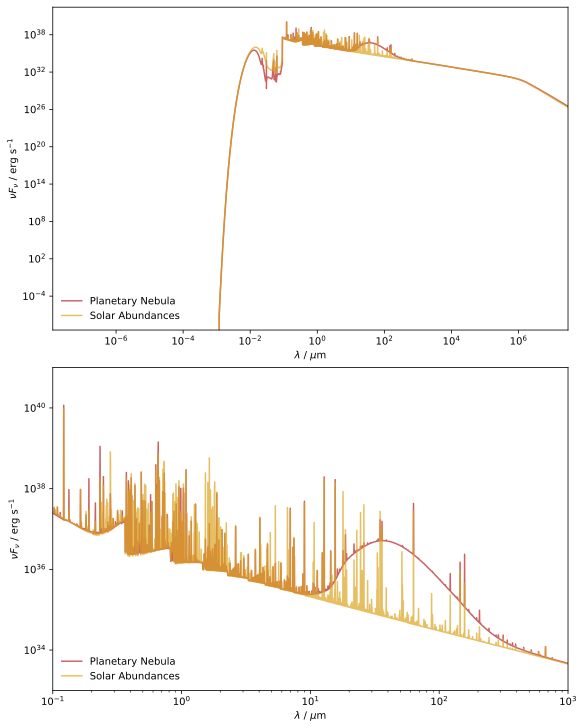

In [5]:
fig, axs = plt.subplots(2, 1, figsize=[8, 10])

axs[0].plot(pn_df['wavel'], pn_df['total'], c='firebrick', label='Planetary Nebula', alpha=0.7)
axs[0].plot(sol_df['wavel'], sol_df['total'], c='goldenrod', label='Solar Abundances', alpha=0.7)

axs[0].set_xlim(np.min(pn_df['wavel']), np.max(pn_df['wavel']))

axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[0].set_xlabel(r'$\lambda$ / $\mu$m')
axs[0].set_ylabel(r'$\nu F_\nu$ / erg s$^{-1}$')

axs[0].legend(loc='lower left')

low = 1e-1
up = 1e3

axs[1].plot(pn_df['wavel'][(pn_df['wavel'] > low) & (pn_df['wavel'] < up)], pn_df['total'][(pn_df['wavel'] > low) & (pn_df['wavel'] < up)], c='firebrick', label='Planetary Nebula', alpha=0.7)
axs[1].plot(sol_df['wavel'][(sol_df['wavel'] > low) & (sol_df['wavel'] < up)], sol_df['total'][(sol_df['wavel'] > low) & (sol_df['wavel'] < up)], c='goldenrod', label='Solar Abundances', alpha=0.7)

axs[1].set_xlim(low, up)
axs[1].set_ylim(1e33, 1e41)

axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[1].set_xlabel(r'$\lambda$ / $\mu$m')
axs[1].set_ylabel(r'$\nu F_\nu$ / erg s$^{-1}$')

axs[1].legend(loc='lower left')

plt.show()
plt.close()

### Simulated Effects Exploration

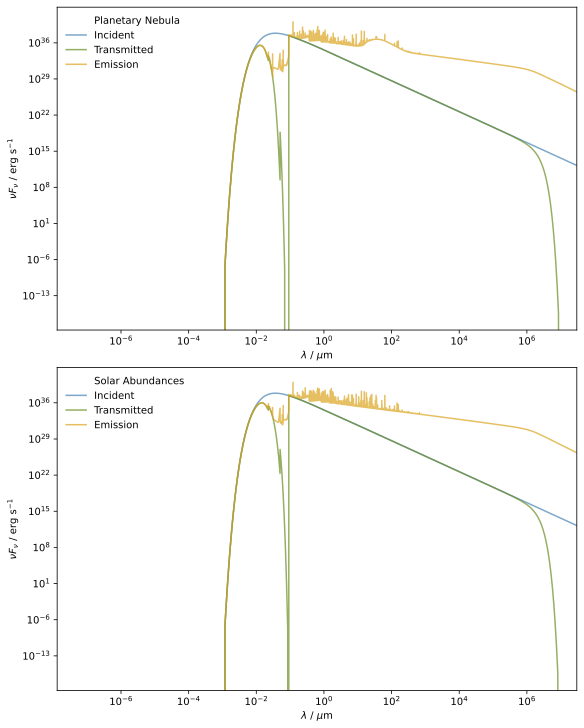

In [6]:
fig, axs = plt.subplots(2, 1, figsize=[8, 10])

axs[0].plot([], [], ' ', label='Planetary Nebula')
axs[0].plot(pn_df['wavel'], pn_df['incident'], c='steelblue', label='Incident', alpha=0.7)
axs[0].plot(pn_df['wavel'], pn_df['trans'], c='olivedrab', label='Transmitted', alpha=0.7)
axs[0].plot(pn_df['wavel'], pn_df['net trans'], c='goldenrod', label='Emission', alpha=0.7)

axs[0].set_xlim(np.min(pn_df['wavel']), np.max(pn_df['wavel']))

axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[0].set_xlabel(r'$\lambda$ / $\mu$m')
axs[0].set_ylabel(r'$\nu F_\nu$ / erg s$^{-1}$')

axs[0].legend(loc='upper left')

axs[1].plot([], [], ' ', label='Solar Abundances')
axs[1].plot(sol_df['wavel'], sol_df['incident'], c='steelblue', label='Incident', alpha=0.7)
axs[1].plot(sol_df['wavel'], sol_df['trans'], c='olivedrab', label='Transmitted', alpha=0.7)
axs[1].plot(sol_df['wavel'], sol_df['net trans'], c='goldenrod', label='Emission', alpha=0.7)

axs[1].set_xlim(np.min(sol_df['wavel']), np.max(sol_df['wavel']))

axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[1].set_xlabel(r'$\lambda$ / $\mu$m')
axs[1].set_ylabel(r'$\nu F_\nu$ / erg s$^{-1}$')

axs[1].legend(loc='upper left')

plt.show()
plt.close()